# Practica 4 - Entregable GANs convolucionales

Carlos Gómez Sáez


## Dataset elegido

Se utiliza **CIFAR-10 completo**, un conjunto de imagenes RGB de tamano `32x32` con 10 clases. Se ha elegido porque introduce mayor complejidad visual que MNIST, incorpora color y textura, y permite probar una variante condicional gracias a sus etiquetas.

## Tecnicas implementadas

Se comparan cuatro configuraciones:

1. **Baseline DCGAN** con entrenamiento estandar.
2. **Actualizacion asimetrica** del discriminador y el generador usando una heuristica basada en la loss del discriminador.
3. **Etiquetas suaves y ruidosas** para reducir la saturacion del discriminador.
4. **GAN condicional (AC-GAN)** para aprovechar las etiquetas de clase.

## Criterio de evaluacion

Para valorar si los trucos ayudan o no, se comparan las curvas de loss y accuracy, asi como la calidad visual y la diversidad de las imagenes generadas. En esta version interesa especialmente observar si el condicionamiento por clase ayuda cuando se trabaja con las 10 categorias del dataset completo.


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.layers import (
    Input, Dense, Reshape, Flatten, Dropout,
    BatchNormalization, LeakyReLU,
    Conv2D, Conv2DTranspose
)
from keras.models import Sequential, Model
from keras.optimizers import Adam

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['figure.figsize'] = (12, 5)
plt.style.use('ggplot')

# - Dimension del vector de ruido latente -
LATENT_DIM = 100
# - Dimension de las imagenes CIFAR-10 -
IMG_SHAPE   = (32, 32, 3)
NUM_CLASSES = 10


In [2]:
# - Carga de datos CIFAR-10 -
# Usamos CIFAR-10 en lugar de MNIST: 50.000 imagenes RGB de 32x32 con 10 categorias.
# Normalizamos a [-1, 1] para que sea compatible con la activacion tanh del generador.

(X_train, y_train), (_, _) = keras.datasets.cifar10.load_data()
X_train = X_train.astype(np.float32) / 127.5 - 1.0  # rango [-1, 1]
y_train = y_train.flatten()  # shape (50000,)

CIFAR10_LABELS = [
    'avion', 'automovil', 'pajaro', 'gato', 'ciervo',
    'perro', 'rana', 'caballo', 'barco', 'camion'
]

print("X_train:", X_train.shape, "  rango:", X_train.min(), X_train.max())
print("y_train:", y_train.shape)


X_train: (50000, 32, 32, 3)   rango: -1.0 1.0
y_train: (50000,)


In [3]:
# - Generador DCGAN -
# El generador parte de un vector de ruido de dimension LATENT_DIM,
# proyecta a un tensor 4x4x512 y luego aplica capas Conv2DTranspose
# (deconvoluciones) para subir la resolucion hasta 32x32x3.
#
# Arquitectura:
#   Ruido (100,)
#   -> Dense(4*4*512) + BN + LeakyReLU
#   -> Reshape(4, 4, 512)
#   -> ConvTranspose 8x8x256  + BN + LeakyReLU
#   -> ConvTranspose 16x16x128 + BN + LeakyReLU
#   -> ConvTranspose 32x32x3  + tanh

def build_generator(latent_dim=LATENT_DIM):
    model = Sequential(name='generator')

    # Proyeccion densa + reshape al volumen inicial
    model.add(Input((latent_dim,)))
    model.add(Dense(4 * 4 * 512, use_bias=False))
    model.add(Reshape((4, 4, 512)))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))

    # Bloque 1: 4x4 -> 8x8
    model.add(Conv2DTranspose(256, kernel_size=4, strides=2,
                              padding='same', use_bias=False))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))

    # Bloque 2: 8x8 -> 16x16
    model.add(Conv2DTranspose(128, kernel_size=4, strides=2,
                              padding='same', use_bias=False))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))

    # Bloque 3: 16x16 -> 32x32, salida RGB con tanh
    model.add(Conv2DTranspose(3, kernel_size=4, strides=2,
                              padding='same', use_bias=False,
                              activation='tanh'))

    model.summary()
    return model

model_gen = build_generator()


I0000 00:00:1776102419.166967 1459331 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14223 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         6,144 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,450,368 (13.16 MB)

 Trainable params: 3,448,576 (13.16 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [4]:
# - Discriminador DCGAN -
# El discriminador recibe una imagen 32x32x3 y aplica bloques Conv2D
# con stride 2 para ir reduciendo la resolucion, seguidos de una capa
# densa que emite una probabilidad de ser real (salida sigmoide).
#
# Arquitectura:
#   Imagen (32, 32, 3)
#   -> Conv2D 64  + LeakyReLU
#   -> Conv2D 128 + BN + LeakyReLU
#   -> Conv2D 256 + BN + LeakyReLU
#   -> Flatten -> Dense(1) + sigmoid

def build_discriminator(img_shape=IMG_SHAPE):
    model = Sequential(name='discriminator')

    model.add(Input(img_shape))

    # Bloque 1: 32x32 -> 16x16
    model.add(Conv2D(64, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))

    # Bloque 2: 16x16 -> 8x8
    model.add(Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))

    # Bloque 3: 8x8 -> 4x4
    model.add(Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))

    # Clasificador final
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    model.summary()
    return model

optimizador_gen = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)
optimizador_dis = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)

model_disc = build_discriminator()
model_disc.compile(loss='binary_crossentropy',
                   optimizer=optimizador_dis,
                   metrics=['accuracy'])


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,513 (2.53 MB)

 Trainable params: 663,745 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)

In [5]:
# - Modelo GAN combinado -
# Para entrenar el generador necesitamos un modelo que encadene
# generador -> discriminador, con los pesos del discriminador congelados.
# Esto permite que el gradiente fluya solo al generador.

model_disc.trainable = False

model_gan = Sequential(name='gan')
model_gan.add(model_gen)
model_gan.add(model_disc)
model_gan.compile(loss='binary_crossentropy', optimizer=optimizador_gen)
model_gan.summary()

# Restauramos tras compilar
model_disc.trainable = True


Model: "gan"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ generator (Sequential)          │ (None, 32, 32, 3)      │     3,450,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Sequential)      │ (None, 1)              │       664,513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,114,881 (15.70 MB)

 Trainable params: 3,448,576 (13.16 MB)

 Non-trainable params: 666,305 (2.54 MB)

In [6]:
def plot_generated_images(generator, epoch, n=8, save=False):
    """
    Genera n imagenes sinteticas y las muestra en una fila.
    Las imagenes se desnormalizan de [-1,1] a [0,1] para visualizarlas.
    """
    noise = np.random.normal(0, 1, (n, LATENT_DIM))
    imgs  = generator.predict(noise, verbose=0)
    imgs  = (imgs + 1.0) / 2.0  # desnormalizar a [0,1]
    imgs  = np.clip(imgs, 0, 1)

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    fig.suptitle(f"Epoca {epoch}", fontsize=12)
    for ax, img in zip(axes, imgs):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    if save:
        plt.savefig(f'gan_epoch_{epoch:04d}.png', dpi=80)
    plt.show()


Baseline:   0%|          | 0/50 [00:00<?, ?it/s]

I0000 00:00:1776102422.862828 1459331 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


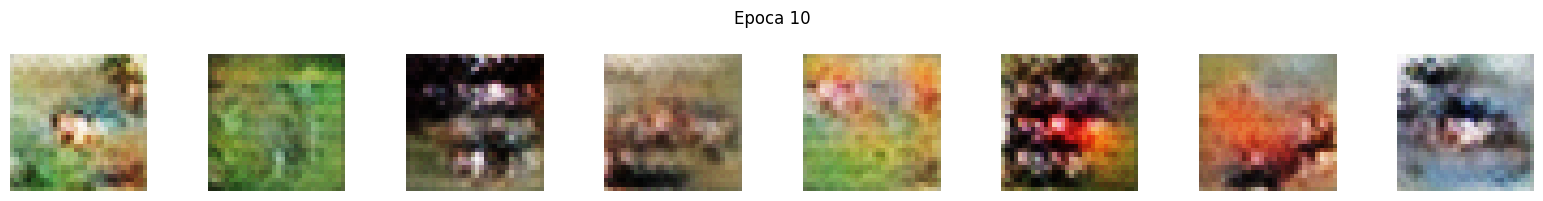

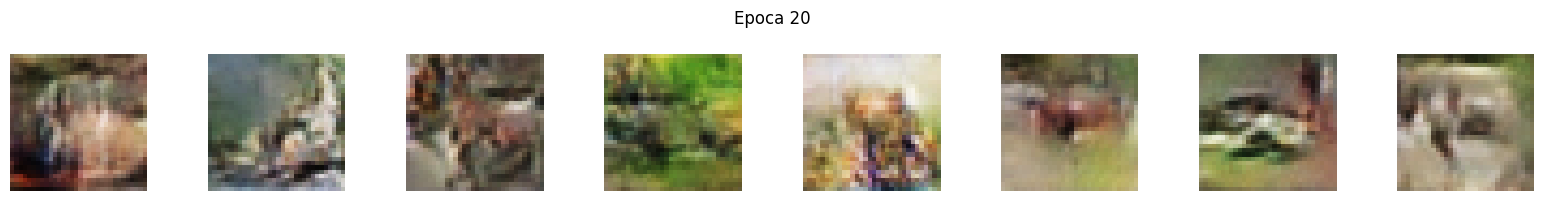

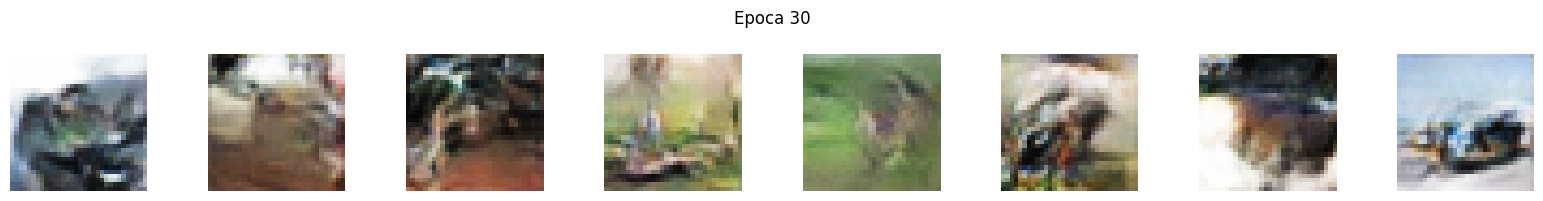

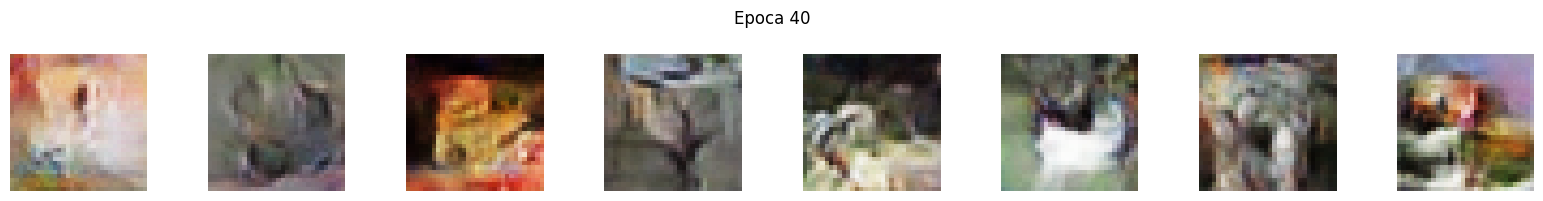

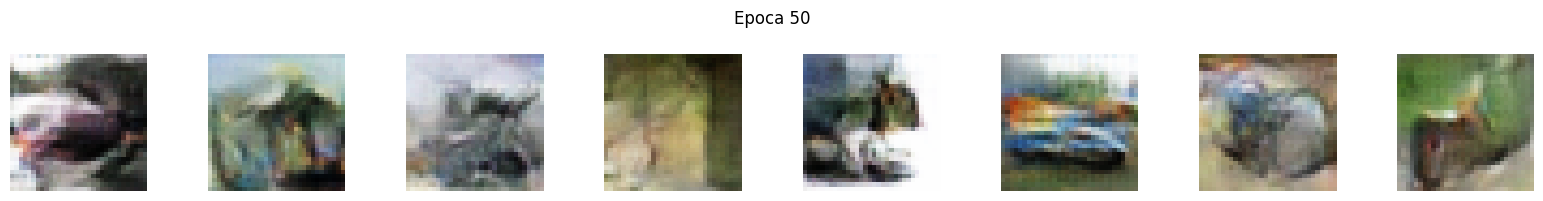

In [7]:
# - Entrenamiento baseline -
# Entrenamiento estandar: cada batch actualiza discriminador 1 vez
# y generador 1 vez. Etiquetas hard (0 y 1 exactos).

EPOCHS     = 50
BATCH_SIZE = 128
N_TRAIN    = len(X_train)  # 50.000 muestras

# Historial de metricas
DD_loss_base = []
GG_loss_base = []
DD_acc_base  = []

dataset = tf.data.Dataset.from_tensor_slices(X_train).\
    shuffle(N_TRAIN, reshuffle_each_iteration=True).\
    batch(BATCH_SIZE)

pb = tqdm(range(EPOCHS), desc="Baseline")

for epoch in pb:
    g_loss_ep = 0.0
    d_loss_ep = 0.0
    d_acc_ep  = 0.0
    n_batches = 0

    for x_real in dataset:
        bs = x_real.shape[0]

        # -- Paso del discriminador --
        noise  = tf.random.normal((bs, LATENT_DIM))
        x_fake = model_gen(noise, training=False)

        xx = tf.concat([x_real, x_fake], axis=0)
        # Etiquetas hard: 1 para reales, 0 para falsas
        yy = tf.concat([tf.ones((bs, 1)), tf.zeros((bs, 1))], axis=0)

        model_disc.trainable = True
        d_metrics = model_disc.train_on_batch(xx, yy)
        d_loss_ep += d_metrics[0]
        d_acc_ep  += d_metrics[1]

        # -- Paso del generador --
        model_disc.trainable = False
        noise2   = tf.random.normal((2 * bs, LATENT_DIM))
        y_target = tf.ones((2 * bs, 1))
        g_loss_ep += model_gan.train_on_batch(noise2, y_target)

        n_batches += 1

    # Promedios por epoch
    d_loss_ep /= n_batches
    d_acc_ep  /= n_batches
    g_loss_ep /= n_batches

    DD_loss_base.append(d_loss_ep)
    GG_loss_base.append(g_loss_ep)
    DD_acc_base.append(d_acc_ep)

    pb.set_description(
        f"[Base] G={g_loss_ep:.4f} D={d_loss_ep:.4f} Dacc={d_acc_ep:.3f}")

    if (epoch + 1) % 10 == 0:
        plot_generated_images(model_gen, epoch + 1)

# Restaurar al final
model_disc.trainable = True


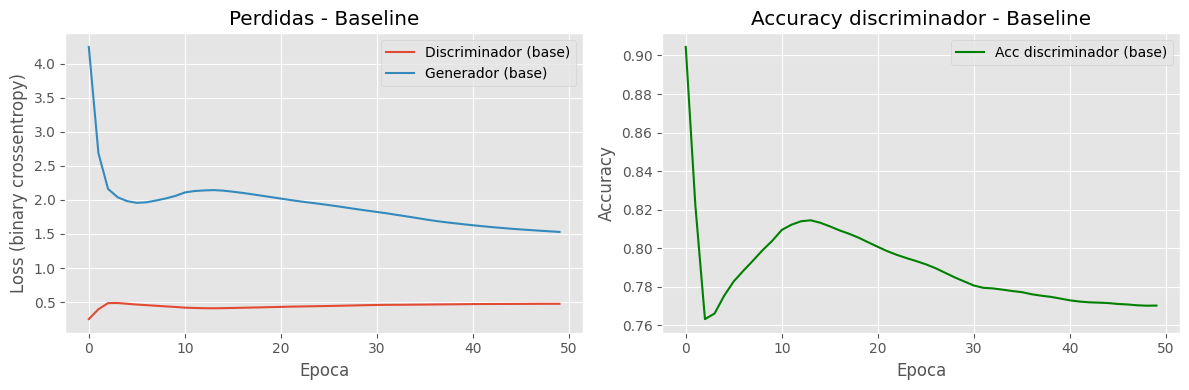

In [8]:
# - Curvas de entrenamiento baseline -
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(DD_loss_base, label='Discriminador (base)')
ax1.plot(GG_loss_base, label='Generador (base)')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss (binary crossentropy)')
ax1.set_title('Perdidas - Baseline')
ax1.legend()

ax2.plot(DD_acc_base, label='Acc discriminador (base)', color='green')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy discriminador - Baseline')
ax2.legend()

plt.tight_layout()
plt.show()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 32, 32, 3)      │         6,144 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,450,368 (13.16 MB)

 Trainable params: 3,448,576 (13.16 MB)

 Non-trainable params: 1,792 (7.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,513 (2.53 MB)

 Trainable params: 663,745 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)

Asimetrico:   0%|          | 0/50 [00:00<?, ?it/s]

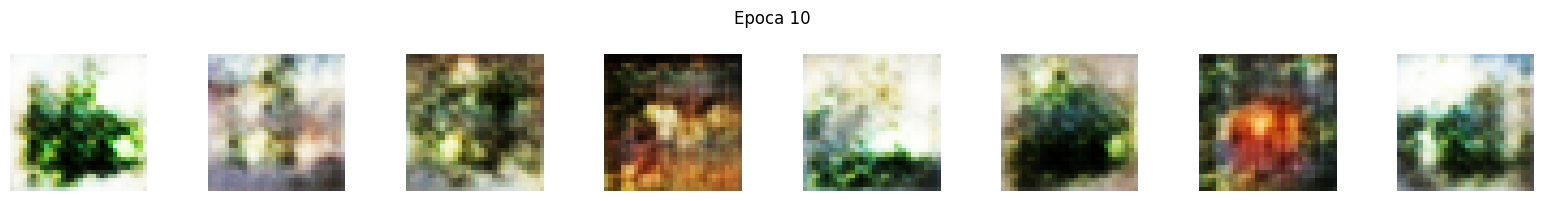

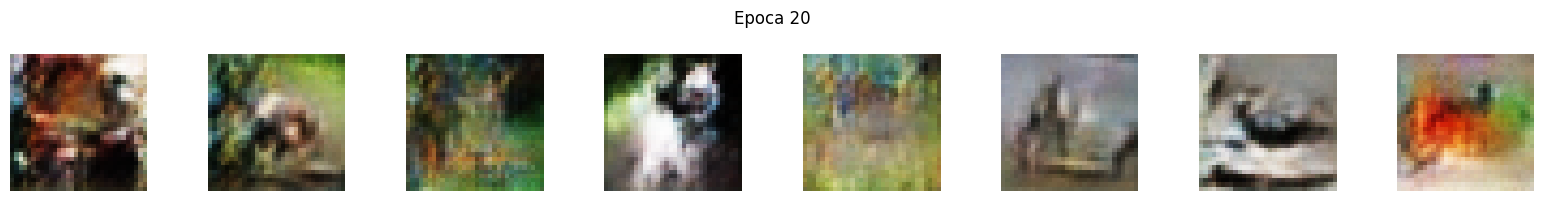

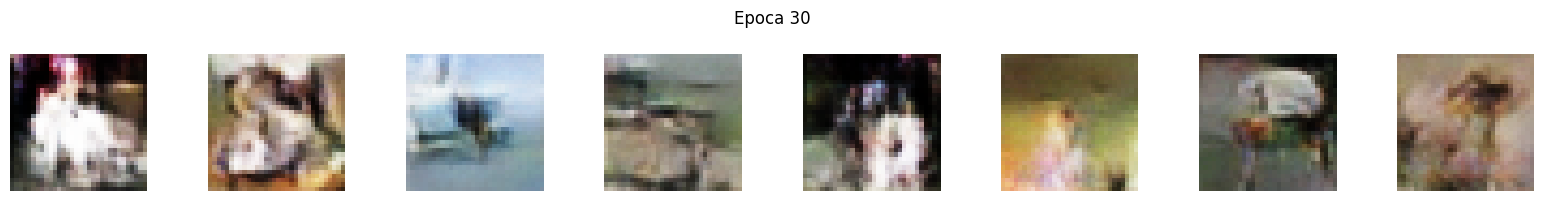

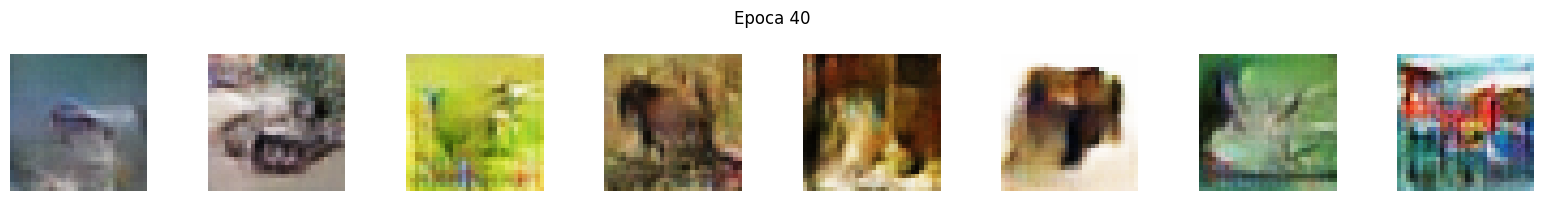

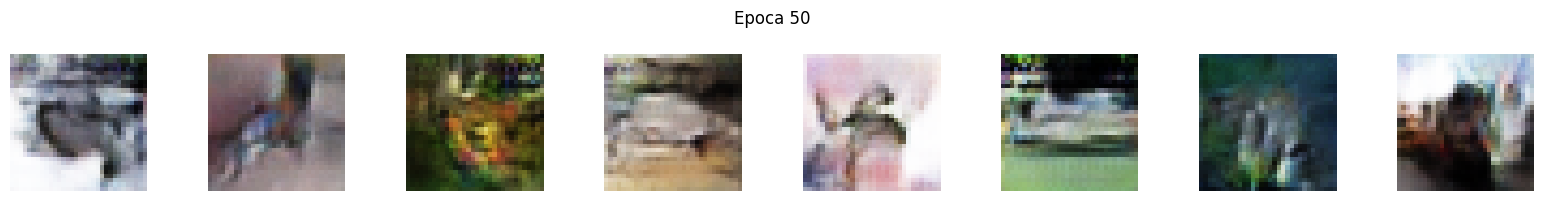

In [9]:
# - Truco 1: Actualizacion asimetrica -
# El discriminador puede volverse demasiado fuerte, haciendo que el
# gradiente del generador sea practicamente nulo (vanishing gradient).
# Estrategia: actualizar el discriminador hasta 2 veces por cada
# actualizacion del generador, PERO solo si su loss sigue siendo alta
# (mayor que un umbral). Si el discriminador ya es muy bueno (loss baja),
# saltamos su actualizacion para darle tiempo al generador.
#
# Heuristica concreta:
#   - Si d_loss (ultimo batch) > THRESH_HIGH -> entrenar discriminador 2 veces
#   - Si d_loss <= THRESH_HIGH              -> entrenar discriminador 1 vez
#   - Siempre se entrena el generador 1 vez

# Reconstruimos modelos frescos para esta comparativa
optimizador_gen2 = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)
optimizador_dis2 = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)

model_gen2  = build_generator()
model_disc2 = build_discriminator()
model_disc2.compile(loss='binary_crossentropy',
                    optimizer=optimizador_dis2,
                    metrics=['accuracy'])

model_disc2.trainable = False
model_gan2 = Sequential(name='gan2')
model_gan2.add(model_gen2)
model_gan2.add(model_disc2)
model_gan2.compile(loss='binary_crossentropy', optimizer=optimizador_gen2)
model_disc2.trainable = True

# Umbral heuristico de loss del discriminador
THRESH_HIGH = 0.7

DD_loss_asym = []
GG_loss_asym = []
DD_acc_asym  = []

pb = tqdm(range(EPOCHS), desc="Asimetrico")

for epoch in pb:
    g_loss_ep = 0.0
    d_loss_ep = 0.0
    d_acc_ep  = 0.0
    n_batches = 0
    last_d_loss = 1.0  # inicio alto para asegurar primera actualizacion

    for x_real in dataset:
        bs = x_real.shape[0]
        noise  = tf.random.normal((bs, LATENT_DIM))
        x_fake = model_gen2(noise, training=False)

        xx = tf.concat([x_real, x_fake], axis=0)
        yy = tf.concat([tf.ones((bs, 1)), tf.zeros((bs, 1))], axis=0)

        # -- Discriminador: 1 o 2 pasos segun heuristica --
        model_disc2.trainable = True
        d_info = model_disc2.train_on_batch(xx, yy)
        last_d_loss = d_info[0]

        if last_d_loss > THRESH_HIGH:
            # El discriminador es debil: le damos otro paso
            noise_extra  = tf.random.normal((bs, LATENT_DIM))
            x_fake_extra = model_gen2(noise_extra, training=False)
            xx2 = tf.concat([x_real, x_fake_extra], axis=0)
            yy2 = tf.concat([tf.ones((bs, 1)), tf.zeros((bs, 1))], axis=0)
            d_info2 = model_disc2.train_on_batch(xx2, yy2)
            # Promediamos las dos actualizaciones
            d_loss_ep += (d_info[0] + d_info2[0]) / 2
            d_acc_ep  += (d_info[1] + d_info2[1]) / 2
        else:
            d_loss_ep += d_info[0]
            d_acc_ep  += d_info[1]

        # -- Generador: siempre 1 paso --
        model_disc2.trainable = False
        noise3   = tf.random.normal((2 * bs, LATENT_DIM))
        y_target = tf.ones((2 * bs, 1))
        g_loss_ep += model_gan2.train_on_batch(noise3, y_target)

        n_batches += 1

    d_loss_ep /= n_batches
    d_acc_ep  /= n_batches
    g_loss_ep /= n_batches

    DD_loss_asym.append(d_loss_ep)
    GG_loss_asym.append(g_loss_ep)
    DD_acc_asym.append(d_acc_ep)

    pb.set_description(
        f"[Asim] G={g_loss_ep:.4f} D={d_loss_ep:.4f} Dacc={d_acc_ep:.3f}")

    if (epoch + 1) % 10 == 0:
        plot_generated_images(model_gen2, epoch + 1)

model_disc2.trainable = True


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 32, 32, 3)      │         6,144 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,450,368 (13.16 MB)

 Trainable params: 3,448,576 (13.16 MB)

 Non-trainable params: 1,792 (7.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,513 (2.53 MB)

 Trainable params: 663,745 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)

Soft labels:   0%|          | 0/50 [00:00<?, ?it/s]

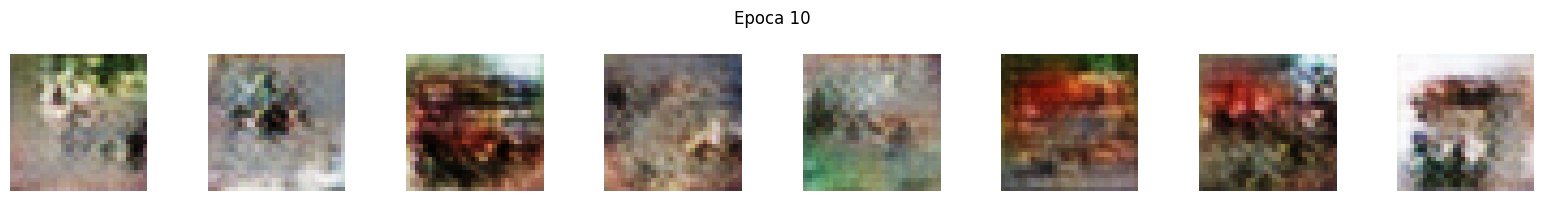

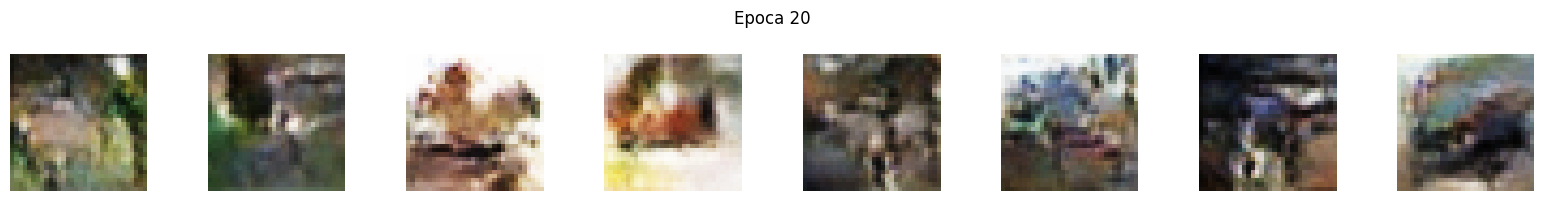

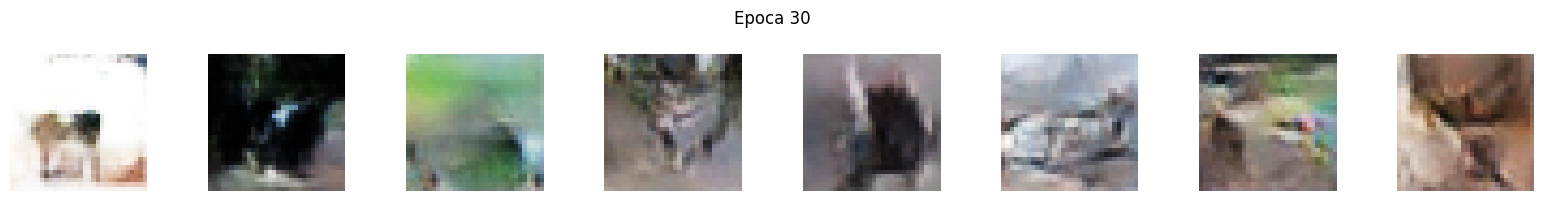

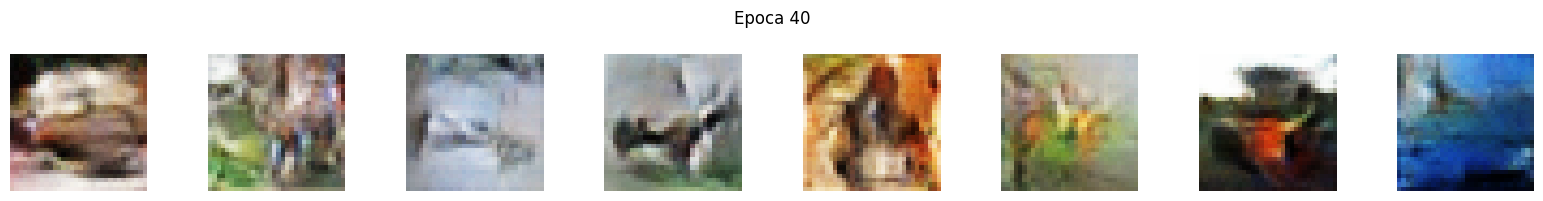

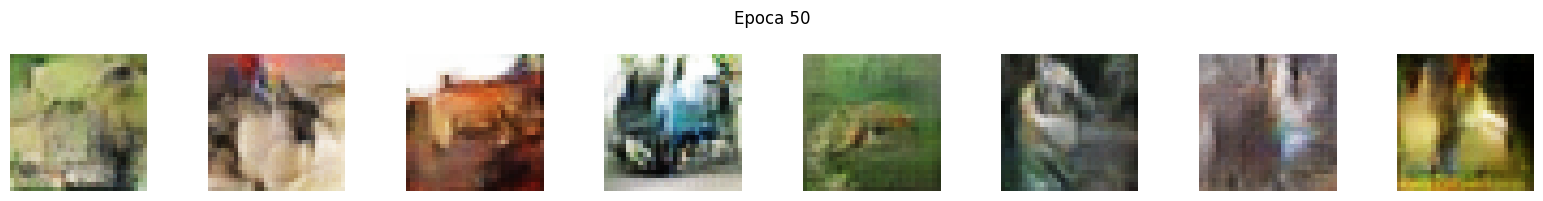

In [10]:
# - Truco 2: Etiquetas suaves (soft labels) y ruidosas -
# En lugar de usar etiquetas hard 0 y 1, usamos muestras de una
# distribucion normal centrada en esos valores con desviacion tipica
# pequena (std=0.05). Esto evita que el discriminador sea demasiado
# seguro, reduciendo el sobreajuste y mejorando la estabilidad.
#
# Etiquetas reales:  Normal(media=0.9, std=0.05), recortadas en [0.8, 1.0]
# Etiquetas falsas:  Normal(media=0.1, std=0.05), recortadas en [0.0, 0.2]
# El recorte evita que una etiqueta cruce al territorio contrario.

optimizador_gen3 = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)
optimizador_dis3 = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)

model_gen3  = build_generator()
model_disc3 = build_discriminator()
model_disc3.compile(loss='binary_crossentropy',
                    optimizer=optimizador_dis3,
                    metrics=['accuracy'])

model_disc3.trainable = False
model_gan3 = Sequential(name='gan3')
model_gan3.add(model_gen3)
model_gan3.add(model_disc3)
model_gan3.compile(loss='binary_crossentropy', optimizer=optimizador_gen3)
model_disc3.trainable = True

LABEL_STD = 0.05  # desviacion tipica del ruido en las etiquetas

DD_loss_soft = []
GG_loss_soft = []
DD_acc_soft  = []

pb = tqdm(range(EPOCHS), desc="Soft labels")

for epoch in pb:
    g_loss_ep = 0.0
    d_loss_ep = 0.0
    d_acc_ep  = 0.0
    n_batches = 0

    for x_real in dataset:
        bs = x_real.shape[0]
        noise  = tf.random.normal((bs, LATENT_DIM))
        x_fake = model_gen3(noise, training=False)

        xx = tf.concat([x_real, x_fake], axis=0)

        # Etiquetas suaves y ruidosas
        real_labels = np.clip(
            np.random.normal(0.9, LABEL_STD, size=(bs, 1)), 0.8, 1.0
        ).astype(np.float32)
        fake_labels = np.clip(
            np.random.normal(0.1, LABEL_STD, size=(bs, 1)), 0.0, 0.2
        ).astype(np.float32)
        yy = np.concatenate([real_labels, fake_labels], axis=0)

        model_disc3.trainable = True
        d_metrics = model_disc3.train_on_batch(xx, yy)
        d_loss_ep += d_metrics[0]
        d_acc_ep  += d_metrics[1]

        # Generador: queremos que el discriminador le ponga 1 (real)
        model_disc3.trainable = False
        noise2   = tf.random.normal((2 * bs, LATENT_DIM))
        y_target = tf.ones((2 * bs, 1))  # hard 1 para el generador
        g_loss_ep += model_gan3.train_on_batch(noise2, y_target)

        n_batches += 1

    d_loss_ep /= n_batches
    d_acc_ep  /= n_batches
    g_loss_ep /= n_batches

    DD_loss_soft.append(d_loss_ep)
    GG_loss_soft.append(g_loss_ep)
    DD_acc_soft.append(d_acc_ep)

    pb.set_description(
        f"[Soft] G={g_loss_ep:.4f} D={d_loss_ep:.4f} Dacc={d_acc_ep:.3f}")

    if (epoch + 1) % 10 == 0:
        plot_generated_images(model_gen3, epoch + 1)

model_disc3.trainable = True


In [11]:
# - Truco 3: Generacion condicional con etiquetas de clase (AC-GAN) -
# El discriminador cumple una doble tarea:
#   1. Predecir si la imagen es real o falsa  (salida sigmoide, loss BCE)
#   2. Predecir la clase de la imagen          (salida softmax, loss CCE)
# Las dos perdidas se combinan con pesos iguales.
# El generador recibe tanto ruido como la clase deseada (one-hot),
# por lo que aprendemos a generar imagenes condicionadas a una clase.
#
# Arquitectura del discriminador condicional:
#   Input imagen (32,32,3)
#   -> bloques Conv
#   -> Flatten
#   |-> Dense(1, sigmoid) : real/falso
#   |-> Dense(10, softmax): clase
#
# Arquitectura del generador condicional:
#   Input ruido (100,) concatenado con one-hot (10,)
#   -> resto igual al DCGAN estandar

# - Generador condicional -
def build_cond_generator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
    # Entrada: vector de ruido + embedding de clase (one-hot)
    z_input = Input(shape=(latent_dim,), name='z_noise')
    c_input = Input(shape=(num_classes,), name='class_label')
    x = tf.keras.layers.Concatenate()([z_input, c_input])

    x = Dense(4 * 4 * 512, use_bias=False)(x)
    x = Reshape((4, 4, 512))(x)
    x = BatchNormalization(momentum=0.8)(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    x = Conv2DTranspose(256, kernel_size=4, strides=2,
                        padding='same', use_bias=False)(x)
    x = BatchNormalization(momentum=0.8)(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    x = Conv2DTranspose(128, kernel_size=4, strides=2,
                        padding='same', use_bias=False)(x)
    x = BatchNormalization(momentum=0.8)(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    x = Conv2DTranspose(3, kernel_size=4, strides=2,
                        padding='same', use_bias=False,
                        activation='tanh')(x)

    model = Model([z_input, c_input], x, name='cond_generator')
    model.summary()
    return model

# - Discriminador condicional (AC-GAN) -
def build_cond_discriminator(img_shape=IMG_SHAPE, num_classes=NUM_CLASSES):
    img_input = Input(shape=img_shape, name='image')

    x = Conv2D(64, kernel_size=4, strides=2, padding='same')(img_input)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.3)(x)

    x = Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = BatchNormalization(momentum=0.8)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.3)(x)

    x = Conv2D(256, kernel_size=4, strides=2, padding='same')(x)
    x = BatchNormalization(momentum=0.8)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.3)(x)

    x = Flatten()(x)

    # Salida 1: real/falso
    out_real = Dense(1, activation='sigmoid', name='real_fake')(x)
    # Salida 2: clase (10 categorias)
    out_class = Dense(num_classes, activation='softmax', name='class_pred')(x)

    model = Model(img_input, [out_real, out_class],
                  name='cond_discriminator')
    model.summary()
    return model

optimizador_gen4 = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)
optimizador_dis4 = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)

cond_gen  = build_cond_generator()
cond_disc = build_cond_discriminator()

# Compilamos el discriminador con las dos perdidas
cond_disc.compile(
    loss={'real_fake': 'binary_crossentropy',
          'class_pred': 'sparse_categorical_crossentropy'},
    loss_weights={'real_fake': 1.0, 'class_pred': 1.0},
    optimizer=optimizador_dis4,
    metrics={'real_fake': 'accuracy'}
)


Model: "cond_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_noise             │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_label         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 110)       │          0 │ z_noise[0][0],    │
│ (Concatenate)       │                   │            │ class_label[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8192)      │    901,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 4, 4, 512) │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 512) │      2,048 │ reshape_3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_18      │ (None, 4, 4, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 8, 8, 256) │  2,097,152 │ leaky_re_lu_18[0… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_19      │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_10 │ (None, 16, 16,    │    524,288 │ leaky_re_lu_19[0… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_20      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_11 │ (None, 32, 32, 3) │      6,144 │ leaky_re_lu_20[0… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,532,288 (13.47 MB)

 Trainable params: 3,530,496 (13.47 MB)

 Non-trainable params: 1,792 (7.00 KB)

Model: "cond_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │      3,136 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_21      │ (None, 16, 16,    │          0 │ conv2d_9[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_21[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 128) │    131,200 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_22      │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 8, 8, 128) │          0 │ leaky_re_lu_22[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 4, 4, 256) │    524,544 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 256) │      1,024 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_23      │ (None, 4, 4, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 4, 4, 256) │          0 │ leaky_re_lu_23[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4096)      │          0 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ real_fake (Dense)   │ (None, 1)         │      4,097 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_pred (Dense)  │ (None, 10)        │     40,970 │ flatten_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 705,483 (2.69 MB)

 Trainable params: 704,715 (2.69 MB)

 Non-trainable params: 768 (3.00 KB)

Condicional:   0%|          | 0/50 [00:00<?, ?it/s]

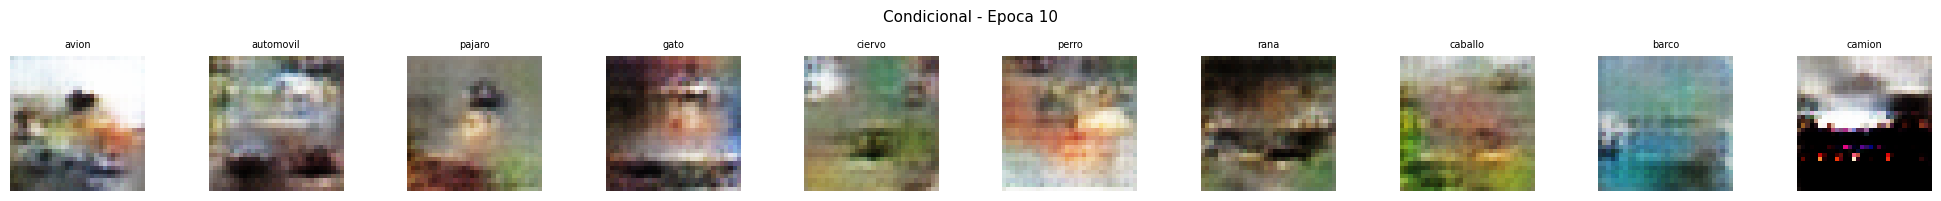

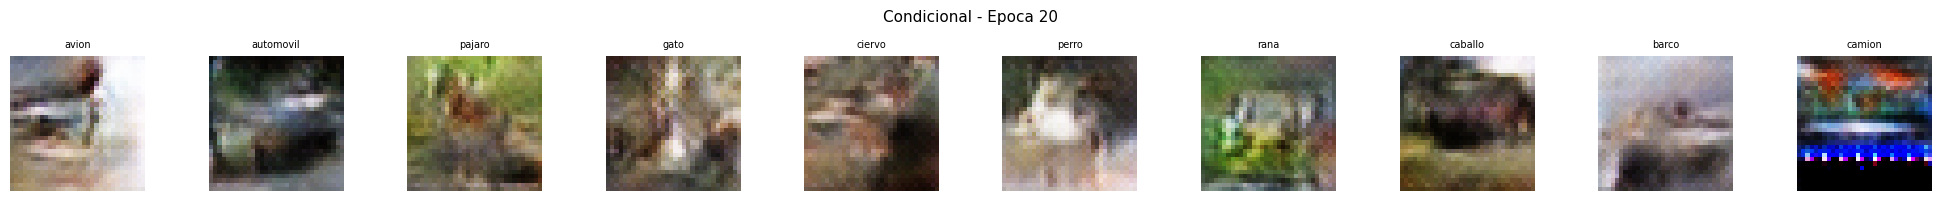

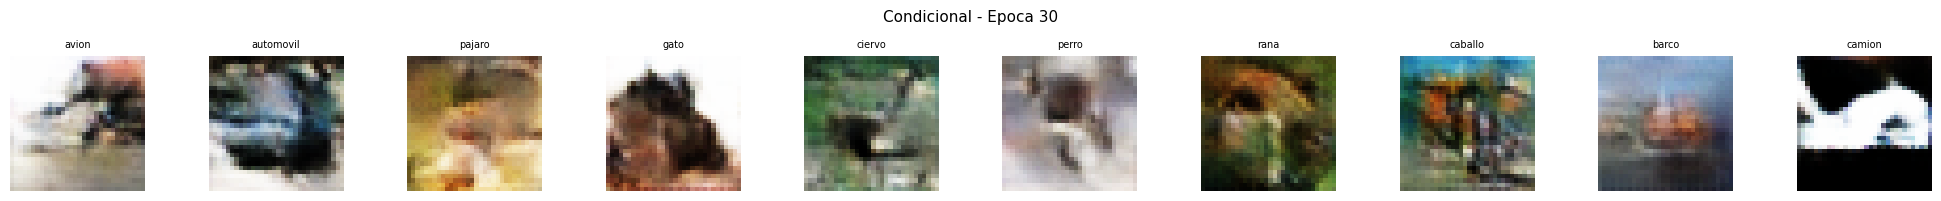

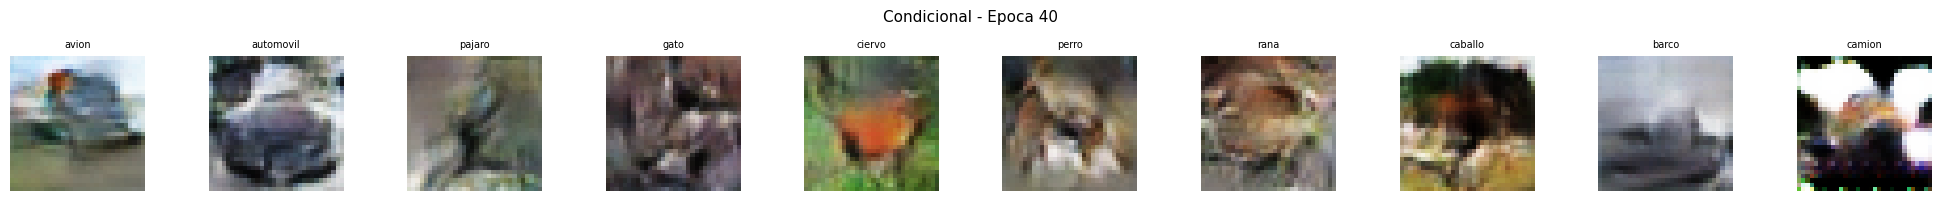

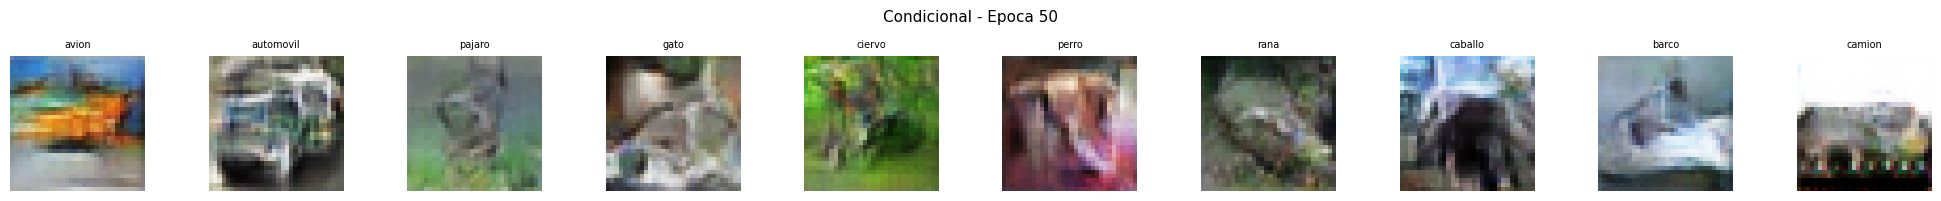

In [13]:
# - Modelo GAN condicional (para entrenar el generador) -
# Congelamos el discriminador y definimos el modelo que pasa
# [ruido, clase] -> generador -> discriminador.

cond_disc.trainable = False

z_in = Input(shape=(LATENT_DIM,), name='z_in')
c_in = Input(shape=(NUM_CLASSES,), name='c_in')
fake_img = cond_gen([z_in, c_in])
disc_out = cond_disc(fake_img)

cond_gan = Model([z_in, c_in], disc_out, name='cond_gan')

# IMPORTANTE: al envolver cond_disc en cond_gan Keras pierde los nombres
# de los outputs individuales ('real_fake', 'class_pred'). Usamos listas
# en lugar de dicts para evitar el ValueError de claves no encontradas.
cond_gan.compile(
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy'],
    loss_weights=[1.0, 1.0],
    optimizer=optimizador_gen4
)

cond_disc.trainable = True

# - Entrenamiento condicional -
DD_loss_cond = []
GG_loss_cond = []
DD_acc_cond  = []

# Creamos el dataset en CPU para no agotar la VRAM con X_train completo.
with tf.device('/CPU:0'):
    dataset_cond = tf.data.Dataset.from_tensor_slices((X_train, y_train)).\
        shuffle(len(X_train), reshuffle_each_iteration=True).\
        batch(BATCH_SIZE)

pb = tqdm(range(EPOCHS), desc="Condicional")

for epoch in pb:
    g_loss_ep = 0.0
    d_loss_ep = 0.0
    d_acc_ep  = 0.0
    n_batches = 0

    for x_real, y_real in dataset_cond:
        bs = x_real.shape[0]

        # -- Discriminador --
        # Imagenes falsas: elegimos clases aleatorias
        fake_classes = np.random.randint(0, NUM_CLASSES, size=(bs,))
        fake_onehot  = np.eye(NUM_CLASSES, dtype=np.float32)[fake_classes]
        noise        = np.random.normal(0, 1, (bs, LATENT_DIM)).astype(np.float32)
        x_fake       = cond_gen.predict([noise, fake_onehot], verbose=0)

        # Concatenamos reales y falsas
        xx = np.concatenate([x_real.numpy(), x_fake], axis=0)

        # Etiquetas real/falso
        yy_rf = np.concatenate(
            [np.ones((bs, 1), dtype=np.float32),
             np.zeros((bs, 1), dtype=np.float32)], axis=0
        )
        # Etiquetas de clase: reales con su clase, falsas con su clase generada
        yy_cls = np.concatenate(
            [y_real.numpy().flatten(),
             fake_classes], axis=0
        )

        cond_disc.trainable = True
        d_metrics = cond_disc.train_on_batch(
            xx, {'real_fake': yy_rf, 'class_pred': yy_cls}
        )
        # d_metrics: [total_loss, real_fake_loss, class_pred_loss, real_fake_accuracy]
        d_loss_ep += d_metrics[0]
        d_acc_ep  += d_metrics[3]

        # -- Generador --
        cond_disc.trainable = False
        gen_classes = np.random.randint(0, NUM_CLASSES, size=(2 * bs,))
        gen_onehot  = np.eye(NUM_CLASSES, dtype=np.float32)[gen_classes]
        noise2      = np.random.normal(0, 1, (2 * bs, LATENT_DIM)).astype(np.float32)

        # El generador quiere engañar: etiquetas 1 (real) para el discriminador.
        # Usamos listas para los targets (consistente con el compile en lista).
        y_target_rf  = np.ones((2 * bs, 1), dtype=np.float32)
        y_target_cls = gen_classes

        g_metrics = cond_gan.train_on_batch(
            [noise2, gen_onehot],
            [y_target_rf, y_target_cls]  # lista en lugar de dict
        )
        g_loss_ep += g_metrics[0]

        n_batches += 1

    d_loss_ep /= n_batches
    d_acc_ep  /= n_batches
    g_loss_ep /= n_batches

    DD_loss_cond.append(d_loss_ep)
    GG_loss_cond.append(g_loss_ep)
    DD_acc_cond.append(d_acc_ep)

    pb.set_description(
        f"[Cond] G={g_loss_ep:.4f} D={d_loss_ep:.4f} Dacc={d_acc_ep:.3f}")

    if (epoch + 1) % 10 == 0:
        # Generamos una imagen por clase
        all_classes = np.eye(NUM_CLASSES, dtype=np.float32)
        noise_show  = np.random.normal(0, 1,
                                       (NUM_CLASSES, LATENT_DIM)).astype(np.float32)
        imgs_show   = cond_gen.predict([noise_show, all_classes], verbose=0)
        imgs_show   = (imgs_show + 1.0) / 2.0
        imgs_show   = np.clip(imgs_show, 0, 1)

        fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(2 * NUM_CLASSES, 2))
        fig.suptitle(f"Condicional - Epoca {epoch+1}", fontsize=11)
        for ax, img, lbl in zip(axes, imgs_show, CIFAR10_LABELS):
            ax.imshow(img)
            ax.set_title(lbl, fontsize=7)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

cond_disc.trainable = True


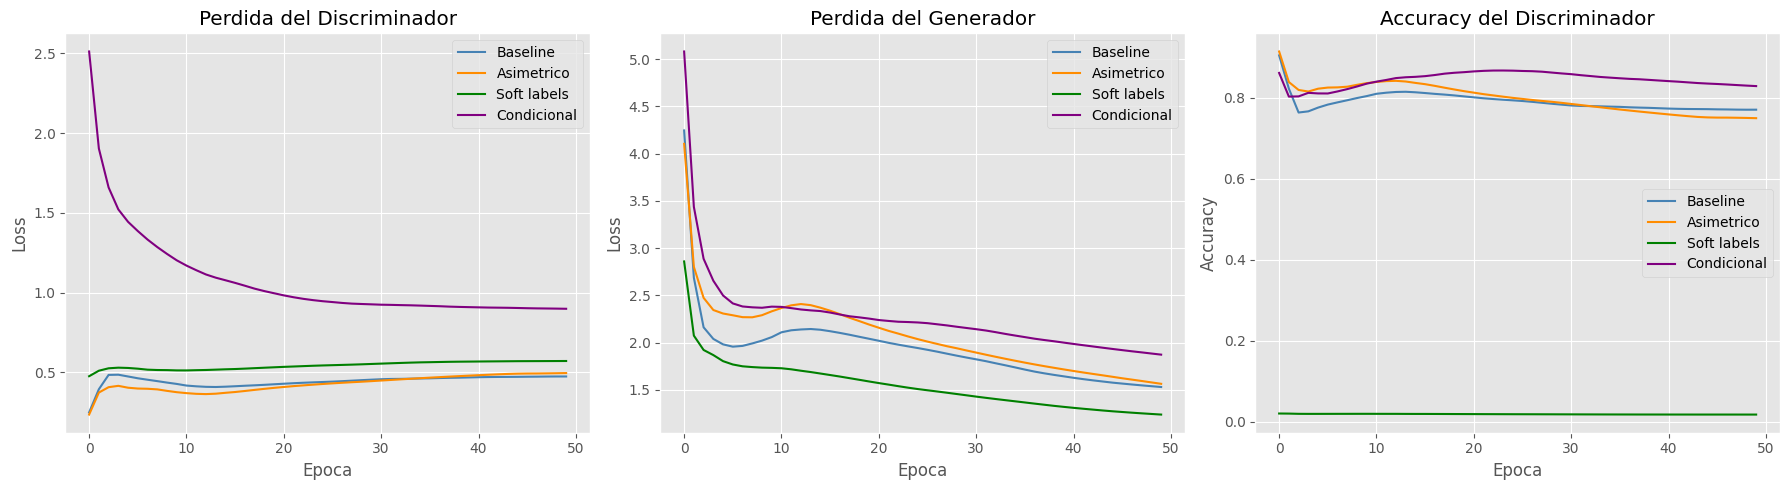

In [14]:
# - Comparacion de las cuatro estrategias -
# Graficamos conjuntamente la evolucion de las perdidas del discriminador
# y del generador para los cuatro experimentos: baseline, asimetrico,
# soft labels y condicional.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Perdida del discriminador --
axes[0].plot(DD_loss_base, label='Baseline',    color='steelblue')
axes[0].plot(DD_loss_asym, label='Asimetrico',  color='darkorange')
axes[0].plot(DD_loss_soft, label='Soft labels', color='green')
axes[0].plot(DD_loss_cond, label='Condicional', color='purple')
axes[0].set_title('Perdida del Discriminador')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()

# -- Perdida del generador --
axes[1].plot(GG_loss_base, label='Baseline',    color='steelblue')
axes[1].plot(GG_loss_asym, label='Asimetrico',  color='darkorange')
axes[1].plot(GG_loss_soft, label='Soft labels', color='green')
axes[1].plot(GG_loss_cond, label='Condicional', color='purple')
axes[1].set_title('Perdida del Generador')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()

# -- Accuracy del discriminador --
axes[2].plot(DD_acc_base, label='Baseline',    color='steelblue')
axes[2].plot(DD_acc_asym, label='Asimetrico',  color='darkorange')
axes[2].plot(DD_acc_soft, label='Soft labels', color='green')
axes[2].plot(DD_acc_cond, label='Condicional', color='purple')
axes[2].set_title('Accuracy del Discriminador')
axes[2].set_xlabel('Epoca')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()


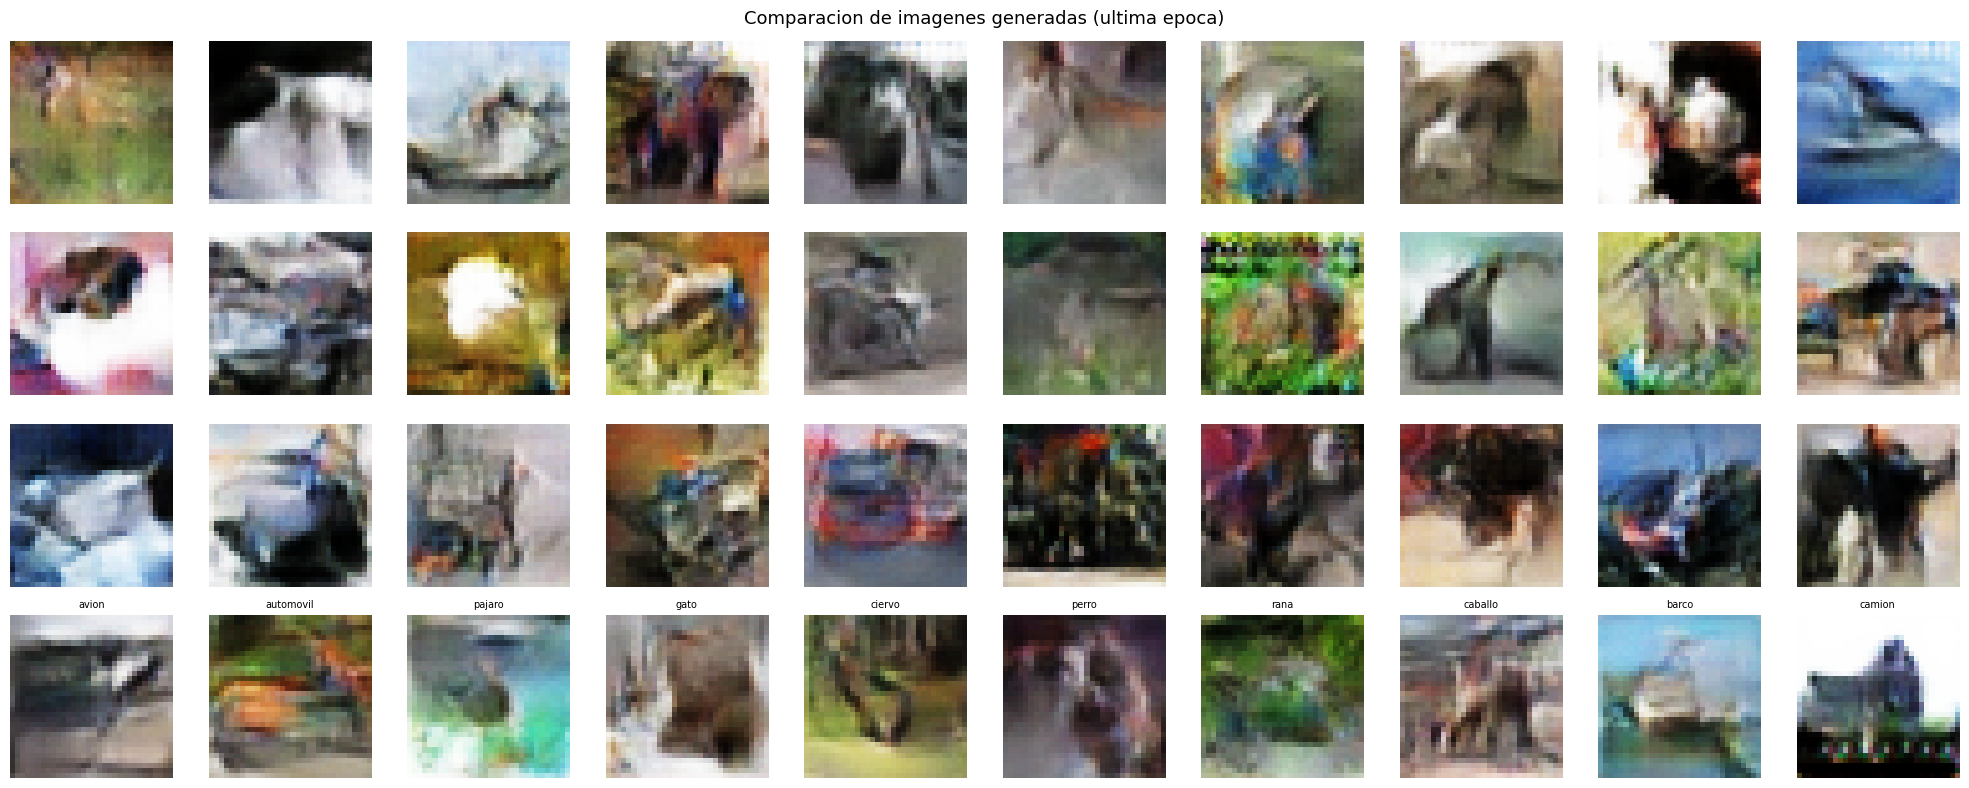

: 

In [ ]:
# - Visualizacion final de los cuatro generadores -
# Generamos un lote de imagenes de cada modelo para comparar
# visualmente la calidad al final del entrenamiento.

# Usamos 10 columnas porque CIFAR-10 tiene 10 clases y asi la fila
# condicional puede mostrar una imagen por clase sin desbordar la rejilla.
fig, axes = plt.subplots(4, 10, figsize=(20, 8))
nombres = ['Baseline', 'Asimetrico', 'Soft labels']

for row_idx, (gen, nombre) in enumerate(
        zip([model_gen, model_gen2, model_gen3], nombres)):
    noise = np.random.normal(0, 1, (10, LATENT_DIM))
    imgs  = gen.predict(noise, verbose=0)
    imgs  = (imgs + 1.0) / 2.0
    imgs  = np.clip(imgs, 0, 1)
    for col_idx in range(10):
        axes[row_idx, col_idx].imshow(imgs[col_idx])
        axes[row_idx, col_idx].axis('off')
    axes[row_idx, 0].set_ylabel(nombre, fontsize=10)

# Generador condicional: una imagen por clase
all_classes_oh = np.eye(NUM_CLASSES, dtype=np.float32)
noise_show     = np.random.normal(0, 1,
                                  (NUM_CLASSES, LATENT_DIM)).astype(np.float32)
imgs_cond = cond_gen.predict([noise_show, all_classes_oh], verbose=0)
imgs_cond = (imgs_cond + 1.0) / 2.0
imgs_cond = np.clip(imgs_cond, 0, 1)
for col_idx in range(NUM_CLASSES):
    axes[3, col_idx].imshow(imgs_cond[col_idx])
    axes[3, col_idx].set_title(CIFAR10_LABELS[col_idx], fontsize=7)
    axes[3, col_idx].axis('off')
axes[3, 0].set_ylabel('Condicional', fontsize=10)

plt.suptitle('Comparacion de imagenes generadas (ultima epoca)', fontsize=13)
plt.tight_layout()
plt.show()


## Conclusiones

La conclusion final del entregable debe apoyarse en dos tipos de evidencia:

- **Numerica**: comparar la estabilidad de las curvas de loss y accuracy.
- **Visual**: comparar la nitidez, diversidad y coherencia de las imagenes generadas.

Al interpretar los resultados, conviene responder explicitamente a estos puntos:

1. Si la arquitectura convolucional mejora la capacidad de generar imagenes frente a una GAN densa sencilla.
2. Si la actualizacion asimetrica estabiliza el entrenamiento o hace al discriminador demasiado dominante.
3. Si las soft labels reducen oscilaciones o saturacion del discriminador.
4. Si la version condicional genera imagenes mas coherentes con la clase objetivo.

En la version de Carlos conviene fijarse tambien en si el modelo condicional consigue separar mejor las 10 categorias de CIFAR-10 o si el coste extra de entrenamiento no compensa la mejora visual.

Un truco se considerara util si mejora la estabilidad del entrenamiento y/o la calidad perceptual de las muestras sin degradar claramente la diversidad.
